# <center> Topic 4. Neural Networks with PyTorch

Сегодня вам предстоит на практике познакомиться с основными концептами обучения нейронных сетей с помощью [`PyTorch`](https://pytorch.org/).

Для этого задания вам наверняка потребуется GPU, поэтому рекомендуется использовать [Google Colab](https://colab.research.google.com). Не забудьте поменять среду выполнения (Runtime -> Change Runtime Type и выбрать T4 GPU). Необходимые данные вы можете загрузить на Google Drive и затем использовать их внутри тетрадки.

Для выполнения задания необходимо следовать по этой тетрадке сверху вниз и заполнять недостающее части кода или отвечать на заданные вопросы.

In [1]:
# Импортируем необходимые библиотеки
# Полезно все импорты держать рядом

import random
from os import listdir, path

import numpy as np
from matplotlib import pyplot
from PIL import Image
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

%matplotlib inline

In [2]:
# Зафиксируем сид для генератора случайных чисел
# Это полезно для воспроизводимости результатов

RANDOM_SEED = 0xC0FFEE

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [3]:
# Определим девайс для вычислений

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cpu


# This Cat does not Exist

Будем создавать изображения котов, которых не существует!

In [4]:
def visualize_images(imgs: torch.Tensor, rows: int = 2):
    imgs = (imgs.transpose(1, 3) + 1) / 2
    cols = imgs.shape[0] // 2 + (imgs.shape[0] % 2)

    # Create a figure to display the images
    fig, axes = pyplot.subplots(rows, cols, figsize=(5, 5))

    # Iterate over the images and display them
    for i, ax in enumerate(axes.flat):
        if i < len(imgs):
            # Display the image
            ax.imshow(imgs[i].cpu().numpy())
            ax.axis("off")  # Turn off axis labels

    # Adjust spacing between images
    pyplot.tight_layout()
    pyplot.axis("off")
    pyplot.show()

## Датасет

Реализуем класс для нашего датасета. В нашем датасете не так много картинок, поэтому может сделать Map-Style датасет. Для этого необходимо определить функции `__getitem__` и `__len__`. Первая отвечает за загрузку отдельного элемента датасета, изображения, а вторая возвращает длину датасета.

In [8]:
!apt-get install unzip
!unzip cat_136.zip -d /content/cat_136

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/cat_136/cat_136/flickr_cat_000168.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000169.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000170.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000171.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000172.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000173.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000178.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000179.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000181.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000185.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000186.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000187.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000188.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000189.jpg  
  inflating: /content/cat_136/cat_136/flickr_cat_000190.jpg  
  

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
from os import listdir, path
from PIL import Image
from torch.utils.data import Dataset


class CatDataset(Dataset):
    """Dataset for cats.
    Read images from disk, convert them to a torch tensor, and resize them to equal squares.

    :path_to_dataset str: path to directory with images
    :size int: size of output images
    """

    def __init__(self, path_to_dataset: str = "cat_136/cat_136", size: int = 64, crop_rate: int = 32):
        self.path_base = path_to_dataset
        self.size = size
        self.crop_rate = crop_rate
        self.photo_names = listdir(path_to_dataset)
        print(f"Found {len(self.photo_names)} images")

    def __getitem__(self, index: int) -> torch.Tensor:
        """Load image from disk and prepare for training.

        :index int: index of image to load
        :return Tensor: torch Tensor with image, shape: [3; self.size; self.size]
        """
        # 1. Load image from disk, create Tensor
        image_path = path.join(self.path_base, self.photo_names[index])
        with Image.open(image_path) as img:
            img = img.convert("RGB")  # Приведение к RGB
            data = np.array(img)  # Convert to NumPy array

        # 2. Random cropping
        h, w, _ = data.shape
        crop_x = np.random.randint(0, self.crop_rate + 1)  # Случайный отступ по X
        crop_y = np.random.randint(0, self.crop_rate + 1)  # Случайный отступ по Y
        cropped_data = data[crop_y : h - crop_y, crop_x : w - crop_x]  # Обрезка

        # 3. Convert to tensor and adjust shape
        image = torch.tensor(cropped_data, dtype=torch.float32).permute(2, 0, 1)  # [C, H, W]

        # 4. Resize using F.interpolate
        image = image.unsqueeze(0)  # Добавляем batch-dimension [1, C, H, W]
        image = F.interpolate(image, size=(self.size, self.size), mode="bilinear", align_corners=False)
        image = image.squeeze(0)  # Убираем batch-dimension, получаем [C, H, W]

        # 5. Normalize to [-1, 1]
        image = (image / 127.5) - 1.0  # Перевод в диапазон [-1, 1]

        return image

    def __len__(self) -> int:
        """Return size of dataset"""
        return len(self.photo_names)

Found 5153 images


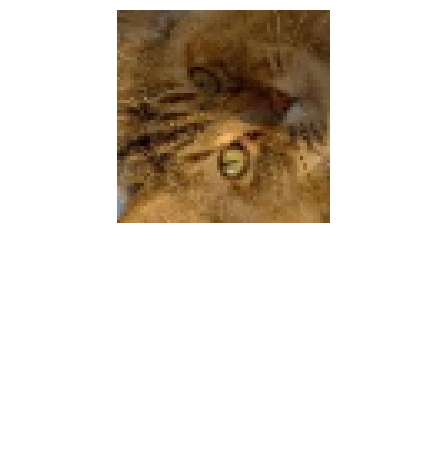

In [12]:
dataset = CatDataset(size=64)
random_images = torch.stack([dataset[0]], dim=0)  # Используем индекс 0
assert list(random_images.shape) == [
    1,
    3,
    64,
    64,
], f"Incorrect shape of image: {random_images[0].shape}, should be [3, 64, 64]"
assert all([-1.0 <= it <= 1.0 for it in random_images.flatten()]), f"Incorrect image normalization"

visualize_images(random_images)

## Модель
Для генерации котов реализуем нейронную сеть типа **GAN**, а именно: **DCGAN**. Модели этого типа состоят из 2 отдельных блоков: генератор и дискриминатор.
Цель генератора — это по случайному шуму генерировать картинку, а дискриминатора — отличать сгенерированную от настоящей.
Каждый блок — это отдельная нейронная сеть, а их выход используется в качестве функции потери у другой!

### Генератор

Для начала реализуем генератор. Предлагается использовать следующую архитектуру:

![](imgs/DCGAN.png)

Для ее реализации вам потребуются модули `nn.BatchNorm2d`, `nn.Conv2d`, `nn.ConvTranspose2D`, `nn.ReLU`.

In [13]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    """Neural network to generate image from noise"""

    def __init__(self, start_size: int = 2, latent_size: int = 32, upsamplings: int = 6, start_channels: int = 1024):
        super().__init__()
        self.start_size = start_size
        self.latent_size = latent_size
        self.start_channels = start_channels
        self.upsamplings = upsamplings

        self.generator = nn.Sequential(*self.get_modules())

    def get_modules(self) -> list[nn.Module]:
        """Create list of modules for specified hyperparameters

        :return list: list of modules
        """
        layers = []

        # Начальный размер (например, 2x2) и количество каналов (например, 1024)
        current_channels = self.start_channels

        # Первый слой: транспонированная свертка с нормализацией
        layers.append(nn.ConvTranspose2d(self.latent_size, current_channels, kernel_size=4, stride=1, padding=0))
        layers.append(nn.BatchNorm2d(current_channels))
        layers.append(nn.ReLU(True))

        # Следующие слои: увеличение изображения и уменьшение числа каналов
        for _ in range(self.upsamplings):
            layers.append(nn.ConvTranspose2d(current_channels, current_channels // 2, kernel_size=4, stride=2, padding=1))
            layers.append(nn.BatchNorm2d(current_channels // 2))
            layers.append(nn.ReLU(True))
            current_channels = current_channels // 2

        # Финальный слой, который дает выходное изображение
        layers.append(nn.ConvTranspose2d(current_channels, 3, kernel_size=4, stride=2, padding=1))  # 3 канала для RGB
        layers.append(nn.Tanh())  # Для нормализации выходного изображения в диапазон [-1, 1]

        return layers

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, batch_size: int) -> torch.Tensor:
        """Generate batch of faked images

        :batch_size int: number of images to generate
        :return Tensor: Tensor w/ generated images, shape [batch size; 3; end size; end size]
        """
        # 1. Generate random noise of starting shape via `random_noise` func
        noise = random_noise(batch_size, self.latent_size, self.start_size, device=self.device)

        # 2. Generate random images
        images = self.generator(noise)

        return images

In [14]:
def random_noise(batch_size: int, channels: int, side_size: int, *, device: torch.device = None) -> torch.Tensor:
    """Generate random noise for batch of images with given size and number of channels."""
    return torch.randn(batch_size, channels, side_size, side_size, device=device)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)

# Генерация 8 изображений
batch_size = 8
generated_images = generator(batch_size)

# Показать размеры сгенерированных изображений
print(generated_images.shape)

torch.Size([8, 3, 640, 640])


### Дискриминатор
Теперь реализуем дискриминатор, его задача по картинке предсказывать 1 класс -- реальное или фейковое изображение.

Предлагается использовать следующую архитектуру:

![](https://github.com/SpirinEgor/HSE.machine_learning/blob/main/06.%20This%20Cat%20Does%20Not%20Exist/imgs/Disc_DCGAN.png?raw=1)

Для ее реализации вам потребуются модули `nn.BatchNorm2d`, `nn.Conv2d`, `nn.ReLU` и `nn.Sigmoid`.

In [16]:
class Discriminator(nn.Module):
    """Neural network to classify image (real or fake)"""

    def __init__(self, downsamplings: int = 4, start_channels: int = 8):
        super().__init__()
        self.downsamplings = downsamplings
        self.start_channels = start_channels

        # Создаем дискриминатор
        self.discriminator = nn.Sequential(*self.get_modules())

    def get_modules(self) -> list[nn.Module]:
        """Создаем список слоев для дискриминатора с учетом гиперпараметров

        :return list: список слоев
        """
        layers = []

        # Начальный размер каналов
        current_channels = self.start_channels

        # Добавляем слои свертки с уменьшением размера изображения
        for _ in range(self.downsamplings):
            layers.append(nn.Conv2d(3 if _ == 0 else current_channels, current_channels * 2, kernel_size=3, stride=2, padding=1))
            layers.append(nn.BatchNorm2d(current_channels * 2))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            current_channels = current_channels * 2

        # Финальный слой для получения предсказания (реальное или фейковое)
        layers.append(nn.Conv2d(current_channels, 1, kernel_size=3, stride=1, padding=0))
        layers.append(nn.Sigmoid())  # Получаем вероятность реальности изображения

        return layers

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Предсказать класс для изображения

        :x Tensor: входной тензор изображений, размер [batch size; 3; H; W]
        :return Tensor: выходной тензор вероятностей, размер [batch size; 1]
        """
        probabilities = self.discriminator(x)
        return probabilities.view(-1)  # Плоский вектор с вероятностями

## Обучение

Будем обучать GAN несколько эпох, при этом каждый шаг обучения состоит из 3 действий:
1. Позитивный шаг для дискриминатора: используем реальные картинки
2. Негативный шаг для дискриминатора: используем сгенерированные картинки
3. Шаг генератора: генерируем картинки, считаем предсказания дискриминатора, используем для обновления генератора.

Во время обучения будем следить за лоссом и дискриминатора, и генератора. При этом тренд лоссов будет немного необычным: сначала будет обучаться дискриминатор, как только он начнет улавливать суть изображений, то и генератор станет обучаться. Однако чем качественнее генератор создает картинки, тем сложнее дискриминатору их различить и его лосс начинает расти.

In [17]:
import torch
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm

class GANTrainer:
    """Trainer for basic GAN on specified dataset"""

    def __init__(self, generator, discriminator, dataset, device):
        self.generator = generator.to(device)
        self.discriminator = discriminator.to(device)
        self.dataset = dataset
        self.device = device

    def configure_optimizers(self, learning_rate: float, weight_decay: float = 1e-2, betas: tuple[float] = (0.5, 0.999)):
        """Create SEPARATE AdamW optimizers for generator and discriminator."""
        gen_optimizer = Adam(self.generator.parameters(), lr=learning_rate, betas=betas, weight_decay=weight_decay)
        disc_optimizer = Adam(self.discriminator.parameters(), lr=learning_rate, betas=betas, weight_decay=weight_decay)
        return gen_optimizer, disc_optimizer

    def configure_dataloader(self, batch_size: int, shuffle: bool) -> DataLoader:
        """Create dataloader for dataset with specified batch size"""
        return DataLoader(self.dataset, batch_size=batch_size, shuffle=shuffle)

    def discriminator_update(self, batch: torch.Tensor, disc_optim, is_positive: bool) -> float:
        """Update step for discriminator"""
        disc_optim.zero_grad()

        # Прогнозируем классы для изображений
        predictions = self.discriminator(batch)

        # Создаем целевые метки: если изображения реальные, метки равны 1, если фальшивые — 0
        target = torch.ones_like(predictions) if is_positive else torch.zeros_like(predictions)

        # Вычисляем лосс
        loss = F.binary_cross_entropy(predictions, target)

        # Обратное распространение
        loss.backward()
        disc_optim.step()

        return loss.item()

    def generator_update(self, batch_size: int, gen_optim) -> float:
        """Update step for generator"""
        gen_optim.zero_grad()

        # Генерируем изображения
        fake_batch = self.generator(batch_size)

        # Получаем прогнозы дискриминатора
        predictions = self.discriminator(fake_batch)

        # Цель — заставить дискриминатор считать фальшивые изображения реальными (т.е. все метки равны 1)
        target = torch.ones_like(predictions)

        # Вычисляем лосс
        loss = F.binary_cross_entropy(predictions, target)

        # Обратное распространение
        loss.backward()
        gen_optim.step()

        return loss.item()

    def run_epoch(self, dataloader, gen_optim, disc_optim) -> tuple[float, float]:
        gen_loss_mean, disc_loss_mean = 0.0, 0.0

        for batch in tqdm(dataloader):
            batch = batch.to(self.device, non_blocking=True)

            # Позитивное обновление для дискриминатора
            disc_loss_mean += self.discriminator_update(batch, disc_optim, is_positive=True)

            # Негативное обновление для дискриминатора
            with torch.no_grad():
                fake_batch = self.generator(batch.shape[0])
            disc_loss_mean += self.discriminator_update(fake_batch, disc_optim, is_positive=False)

            # Обновление для генератора
            gen_loss_mean += self.generator_update(batch.shape[0], gen_optim)

        gen_loss_mean /= len(dataloader)
        disc_loss_mean /= len(dataloader)
        return gen_loss_mean, disc_loss_mean

    def train(self, n_epochs: int = 50, batch_size: int = 8, learning_rate: float = 1e-4, visualize_every_epoch: int = 10):
        gen_optim, disc_optim = self.configure_optimizers(learning_rate)
        dataloader = self.configure_dataloader(batch_size, shuffle=True)

        for epoch in range(n_epochs):
            gen_loss_mean, disc_loss_mean = self.run_epoch(dataloader, gen_optim, disc_optim)

            if (epoch + 1) % visualize_every_epoch == 0:
                with torch.no_grad():
                    fake_images = self.generator(6)
                visualize_images(fake_images, rows=2)

            print(f"Epoch {epoch+1} | Discriminator loss: {disc_loss_mean:.4f} | Generator loss: {gen_loss_mean:.4f}")

In [18]:
generator = Generator()
discriminator = Discriminator()
dataset = CatDataset(size=128)

trainer = GANTrainer(generator, discriminator, dataset, device)

Found 5153 images


In [ ]:
trainer.train(n_epochs=2, batch_size=4, visualize_every_epoch=1)

 84%|████████▍ | 1086/1289 [47:42<09:01,  2.67s/it]

## Сохранение модели

После обучения модели необходимо сохранить модель, создадим общий чекпоинт с дискриминатором и генератором.

Для этого будут полезны метод `state_dict` у любого модуля в Torch и функция `torch.save`.

In [22]:
def dump_checkpoint(generator: Generator, discriminator: Discriminator, filename: str):
    """Сохранить модели в файл."""
    torch.save({
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
    }, filename)

In [23]:
dump_checkpoint(generator, discriminator, "checkpoint.pt")

# Загрузка модели

Проверим, что модель загружается с диска и работает.

Для этого будут полезны методы `load_state_dict` у любого модуля в Torch и функция `torch.load`.

In [24]:
def load_checkpoint(filename: str) -> tuple[Generator, Discriminator]:
    """Загрузить модели из файла."""
    checkpoint = torch.load(filename)
    generator = Generator()
    discriminator = Discriminator()
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    return generator, discriminator

In [25]:
generator, discriminator = load_checkpoint("checkpoint.pt")
generator = generator.to(device)
discriminator = discriminator.to(device)

<ipython-input-24-74aebcfebbfb>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename)


Predicted classes: FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAKE, FAK

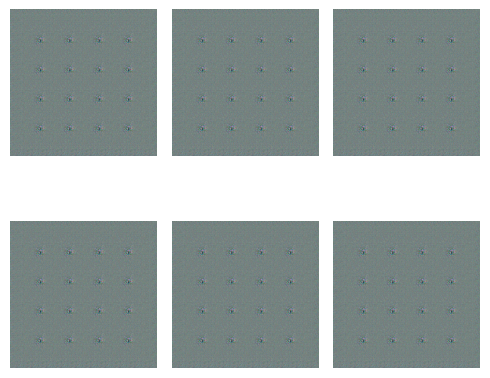

In [26]:
with torch.inference_mode():
    fake_images = generator(6)
    probs = discriminator(fake_images)
    prediction = [["FAKE", "REAL"][i > 0.5] for i in probs]

print(f"Predicted classes: {', '.join(prediction)}")
visualize_images(fake_images)

При сдаче практики также прикрепите полученный чекпоинт!